# Uzak Bir Galaksinin Parlaklık Analizi
## YZM212 Makine Öğrenmesi 4. Laboratuvar Ödevi

Bu çalışmada Bayesyen çıkarım ve MCMC yöntemi kullanılarak gürültülü gözlem verilerinden bir gök cisminin gerçek parlaklığı ve gözlem hatası tahmin edilecektir.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [2]:
true_mu = 150.0
true_sigma = 10.0
n_obs = 50

np.random.seed(42)
data = true_mu + true_sigma * np.random.randn(n_obs)

print(data[:10])

[154.96714153 148.61735699 156.47688538 165.23029856 147.65846625
 147.65863043 165.79212816 157.67434729 145.30525614 155.42560044]


### Veri Miktarının Etkisi

Gözlem sayısı 50’den 5’e düşürüldüğünde posterior dağılımı belirgin şekilde genişler. Bu durum belirsizliğin arttığını gösterir. Daha az veri olduğu için model parametreler hakkında daha az bilgiye sahiptir. Bu nedenle hem tahminler daha değişken olur hem de güven aralıkları genişler.

## Bayesyen Model

Bu bölümde log-likelihood, log-prior ve log-posterior fonksiyonları tanımlanacaktır.

In [3]:
def log_likelihood(theta, data):
    mu, sigma = theta

    if sigma <= 0:
        return -np.inf

    return -0.5 * np.sum(((data - mu) / sigma) ** 2 + np.log(2 * np.pi * sigma**2))

In [4]:
def log_prior(theta):
    mu, sigma = theta

    if 0 < mu < 300 and 0 < sigma < 50:
        return 0.0

    return -np.inf

### Prior Etkisi

Eğer parlaklık için çok dar bir prior (örneğin 100-110 arası) seçilirse, posterior dağılım gerçek veriden ziyade prior’un etkisi altında kalır. Bu durumda model, gerçek değer 150 civarında olsa bile tahminlerini dar prior aralığına çekmeye çalışır. Bu durum Bayesyen yöntemde prior seçiminin sonuçlar üzerindeki etkisini açıkça göstermektedir.

In [5]:
def log_probability(theta, data):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, data)

## MCMC Örnekleme

Bu aşamada `emcee` kütüphanesi ile posterior dağılımdan örnekler üretilecektir.

In [6]:
initial = [140, 5]
n_walkers = 32
n_dim = 2

pos = initial + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(
    n_walkers,
    n_dim,
    log_probability,
    args=(data,)
)

sampler.run_mcmc(pos, 2000 )

State([[146.59998341  10.42092649]
 [145.76650675  11.60857143]
 [146.31910041   9.14490759]
 [145.90858789   9.51951477]
 [149.50001792  10.6971051 ]
 [148.23997762   7.57732972]
 [145.92371546   9.17289208]
 [148.26406017  10.31640188]
 [148.47276681   9.17008242]
 [147.57449242  10.21570077]
 [150.23734833   9.44225594]
 [147.03952781   9.89079477]
 [149.14711346  11.12816338]
 [148.27233147   9.8407065 ]
 [148.62613862   9.28586118]
 [145.98667835  10.18979161]
 [145.24739774  10.44528554]
 [149.43608698   9.22811801]
 [146.40245485   8.43770594]
 [145.78330318  10.51884913]
 [147.85401389   8.45182821]
 [147.42844684   9.44192722]
 [149.10109886   8.90341593]
 [146.47069205  10.31726797]
 [147.33120777   8.41840442]
 [148.72370404   8.55018824]
 [147.63410866   8.90291161]
 [147.9781292   10.78401907]
 [148.89230751   8.80346579]
 [147.55857922  11.08242989]
 [149.9933675    9.75677827]
 [147.16186895   9.84247395]], log_prob=[-183.10672788 -185.10921796 -182.75317262 -183.1127120

In [7]:
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

print(flat_samples.shape)

(3200, 2)


In [8]:
mu_samples = flat_samples[:, 0]
sigma_samples = flat_samples[:, 1]

mu_median = np.median(mu_samples)
sigma_median = np.median(sigma_samples)

mu_p16, mu_p84 = np.percentile(mu_samples, [16, 84])
sigma_p16, sigma_p84 = np.percentile(sigma_samples, [16, 84])

mu_abs_error = abs(mu_median - true_mu)
sigma_abs_error = abs(sigma_median - true_sigma)

print("mu median:", mu_median)
print("mu %16:", mu_p16)
print("mu %84:", mu_p84)
print("mu mutlak hata:", mu_abs_error)

print()

print("sigma median:", sigma_median)
print("sigma %16:", sigma_p16)
print("sigma %84:", sigma_p84)
print("sigma mutlak hata:", sigma_abs_error)

mu median: 147.7862533013905
mu %16: 146.42607424611114
mu %84: 149.07203239392416
mu mutlak hata: 2.213746698609498

sigma median: 9.492117308421232
sigma %16: 8.554305529485836
sigma %84: 10.531275879457391
sigma mutlak hata: 0.507882691578768


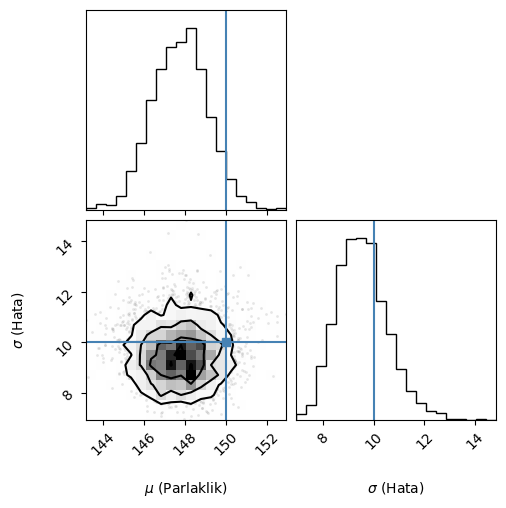

In [9]:
fig = corner.corner(
    flat_samples,
    labels=[r"$\mu$ (Parlaklik)", r"$\sigma$ (Hata)"],
    truths=[true_mu, true_sigma]
)

plt.show()

## Corner Plot

Yukarıdaki grafik, mu (parlaklık) ve sigma (hata) parametrelerinin posterior dağılımlarını ve aralarındaki ilişkiyi göstermektedir.

In [10]:
fig.savefig("corner_plot.png", dpi=300, bbox_inches="tight")

## Parametre Karşılaştırma Tablosu

| Değişken | Gerçek Değer (Girdi) | Tahmin Edilen (Median) | Alt Sınır (%16) | Üst Sınır (%84) | Mutlak Hata |
|----------|-----------------------|-------------------------|-----------------|-----------------|-------------|
| μ (Parlaklık) | 150.0 | 147.7863 | 146.4261 | 149.0720 | 2.2137 |
| σ (Hata Payı) | 10.0 | 9.4921 | 8.5543 | 10.5313 | 0.5079 |

## Merkezi Eğilim ve Doğruluk Analizi

Elde edilen sonuçlara göre, μ parametresi için bulunan median değer gerçek 150.0 değerine oldukça yakındır. Mutlak hata düşük olduğu için modelin doğruluğu yüksektir.

## Tahmin Hassasiyeti

μ parametresinin güven aralığı σ parametresine göre daha dardır. Bunun nedeni ortalamanın tahmininin daha kararlı olmasıdır. σ parametresi verideki saçılmayı temsil ettiği için daha fazla belirsizlik içerir. n=50 gözlem sayısı μ tahmininin daha hassas olmasını sağlamıştır.

## Korelasyon Analizi

Corner plot incelendiğinde μ ve σ arasında güçlü bir korelasyon olmadığı görülmektedir. Dağılımın şekli parametrelerin büyük ölçüde bağımsız olduğunu göstermektedir.

## Sonuçların Analizi

Bu çalışmada Bayesyen çıkarım ve MCMC yöntemi kullanılarak gürültülü gözlem verilerinden bir gök cisminin gerçek parlaklığı ve gözlem hatası tahmin edilmiştir.

Elde edilen sonuçlara göre, parlaklık parametresi için bulunan median değer 147.7863’tür. Bu değer gerçek 150.0 değerine oldukça yakındır. Mutlak hata 2.2137 olarak bulunmuştur. Bu sonuç, modelin gürültülü veriye rağmen gerçek değere yakın bir tahmin üretebildiğini göstermektedir.

Hata payı parametresi için bulunan median değer 9.4921 dir. Gerçek değer 10.0 olduğundan, mutlak hata 0.5079’dur. Bu da modelin gözlem gürültüsünü makul doğrulukla tahmin ettiğini göstermektedir.

Tablo incelendiğinde, mu parametresinin güven aralığının  sigma parametresine göre daha dar olduğu görülmektedir. Bunun nedeni, ortalama tahmininin istatistiksel olarak daha kararlı olmasıdır. Standart sapma ise verideki saçılmayı temsil ettiği için daha fazla belirsizlik içerir.

Corner plot grafiği incelendiğinde, mu ve sigma parametreleri arasında güçlü bir korelasyon olmadığı söylenebilir. Dağılımın genel yapısı, parametrelerin büyük ölçüde bağımsız davrandığını; ancak hafif düzeyde bir ilişki bulunabileceğini düşündürmektedir.

Sonuç olarak, Bayesyen yöntemler gürültülü astronomik veriler üzerinde hem parametre tahmini hem de belirsizlik analizi yapmak için etkili bir araçtır.